# Lectura de datos en ngspice para Lib Razavi
Lectura y graficación de resultados de ngspice usando `spicelib`, `matplotlib`, `prettytable` y `si_prefix`. Es la versión para ngspice de `LTspice_DC_Sweep.ipynb`: el mismo circuito (`DC_Sweep_Razavi`) con el mismo modelo de primer orden.

Archivos usados en este notebook:
- `DC_Sweep_Razavi.cir` → netlist de ngspice (equivalente a `DC_Sweep_Razavi.asc`)
- `razavi_cmos.lib` → librería con el modelo Level 1 y los parámetros de ruido (los `.MODEL` son idénticos a los de `LTspice/Razavi/razavi_cmos.lib`; solo cambia cómo se declaran `w`, `l` y `m` en el `.subckt`)
- `op` → `DC_Sweep_Razavi.log`
- `dc` → `DC_Sweep_Razavi_ngspice.raw`

## 1. Imports
Se cargan una sola vez, se usan en todas las secciones siguientes. La fuente Arial es opcional: si no está instalada, matplotlib usa la siguiente de la lista sin mostrar advertencias.

In [1]:
import logging
import os
import re
import shutil
import subprocess

import numpy as np
import matplotlib.pyplot as plt

from spicelib import RawRead

from prettytable import PrettyTable
from si_prefix import si_format as num2eng

# Arial si existe; si no, una alternativa. Se silencia el aviso de fuente faltante.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

# Colores: ngspice en naranja, LTspice en gris (comparacion)
C_NGSPICE = "#eb6834"
C_LTSPICE = "#52514e"
C_HAND = "#2a78d6"

# numpy renombro trapz -> trapezoid en versiones recientes; esto funciona con ambas
trapz = getattr(np, "trapezoid", None) or np.trapz

## 2. Funciones auxiliares
`read_op_log` extrae del log de ngspice las líneas `@m.<instancia>.m1[<parametro>] = <valor>` que imprime el netlist después del `.op`. `ngspice_available` indica si el ejecutable está en el `PATH`.

In [2]:
def read_op_log(path):
    """Lee el log de ngspice y devuelve {'u1:M1': {'id': ..., 'gm': ...}, 'u2:M1': {...}}."""
    pat = re.compile(r"^@m\.(\w+)\.m1\[(\w+)\]\s*=\s*([-+0-9.eE]+)")
    devices = {}
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pat.match(line.strip())
            if not m:
                continue
            inst, param, value = m.groups()
            name = f"{inst[1:]}:M1"          # xu1 -> u1:M1 (mismo nombre que en LTspice)
            devices.setdefault(name, {})[param] = float(value)
    return devices


def ngspice_available():
    return shutil.which("ngspice") is not None

## 3. Simulación (opcional)
Si `ngspice` está instalado, esta celda vuelve a correr el netlist y regenera el log y el `.raw`. Si no, se usan los archivos que ya están en la carpeta. Debe ejecutarse desde la carpeta del notebook, porque el netlist hace `.include razavi_cmos.lib` con ruta relativa.

In [3]:
NETLIST = "DC_Sweep_Razavi.cir"
LOG_NGSPICE = "DC_Sweep_Razavi.log"
RAW_NGSPICE_DC = "DC_Sweep_Razavi_ngspice.raw"

RUN_SIMULATION = True

if RUN_SIMULATION and ngspice_available():
    res = subprocess.run(["ngspice", "-b", "-o", LOG_NGSPICE, NETLIST],
                         capture_output=True, text=True)
    print("ngspice terminó con código", res.returncode)
elif RUN_SIMULATION:
    print("ngspice no está en el PATH; se usan los archivos existentes.")

for fname in (LOG_NGSPICE, RAW_NGSPICE_DC):
    print(f"{fname}: {'OK' if os.path.exists(fname) else 'NO ENCONTRADO'}")

ngspice terminó con código 0
DC_Sweep_Razavi.log: OK
DC_Sweep_Razavi_ngspice.raw: OK


## 4. Punto de operación (`.op`)
Lee `DC_Sweep_Razavi.log` y muestra el punto de operación de cada transistor en una tabla (filas = parámetros, columnas = transistores).

Diferencias de convención respecto a LTspice:
- ngspice reporta el PMOS con $I_D$, $V_{GS}$, $V_{DS}$ y $V_{BS}$ en la convención interna del modelo (sin el signo negativo que muestra LTspice), pero `Vth` y `Vdsat` sí salen negativos.
- `Cgs`, `Cgd` y `Cgb` de ngspice ya incluyen la capacitancia de traslape (LTspice las separa en `Cgsov`, `Cgdov`, `Cgbov`). Por ejemplo, $C_{GS}=C_{GS,int}+C_{GSO}W = 1.04\,\text{fF}+0.955\,\text{fF}\approx 1.99\,\text{fF}$ en saturación.

In [4]:
op_data = read_op_log(LOG_NGSPICE)
devices = list(op_data.keys())

# (nombre en la tabla, parametro de ngspice)
params = [("Id", "id"), ("Vgs", "vgs"), ("Vds", "vds"), ("Vbs", "vbs"),
          ("Vth", "von"), ("Vdsat", "vdsat"),
          ("Gm", "gm"), ("Gds", "gds"), ("Gmb", "gmbs"),
          ("Cbd", "cbd"), ("Cbs", "cbs"),
          ("Cgs", "cgs"), ("Cgd", "cgd"), ("Cgb", "cgb")]

table = PrettyTable()
table.field_names = ["Parámetro"] + devices

for label, key in params:
    row = [label]
    for dev in devices:
        row.append(num2eng(op_data[dev][key]))
    table.add_row(row)

print(f"Punto de operación — {LOG_NGSPICE}\n")
print(table)

Punto de operación — DC_Sweep_Razavi.log

+-----------+---------+----------+
| Parámetro |  u1:M1  |  u2:M1   |
+-----------+---------+----------+
|     Id    |  75.7 µ |  37.8 µ  |
|    Vgs    | 900.0 m | 900.0 m  |
|    Vds    | 900.0 m | 900.0 m  |
|    Vbs    |   0.0   |   0.0    |
|    Vth    | 400.0 m | -400.0 m |
|   Vdsat   | 500.0 m | -500.0 m |
|     Gm    | 302.8 µ | 151.4 µ  |
|    Gds    |  6.9 µ  |  3.5 µ   |
|    Gmb    | 110.6 µ |  55.3 µ  |
|    Cbd    | 823.1 a | 823.1 a  |
|    Cbs    | 823.1 a | 823.1 a  |
|    Cgs    |  2.0 f  |  2.0 f   |
|    Cgd    | 954.8 a | 954.8 a  |
|    Cgb    |   0.0   |   0.0    |
+-----------+---------+----------+


## 5. DC Sweep
Corriente de drenador, transconductancia ($g_m$) y conductancia de salida ($g_{ds}$) de U1 al barrer $V_{DS}$ de 0 a $V_{DD}$ con $V_{GS}=V_{DD}/2$ fijo. A diferencia de LTspice, aquí $g_m$ y $g_{ds}$ se guardan directamente del modelo en cada punto del barrido (`save @m.xu1.m1[gm]`, `[gds]`), sin derivar numéricamente.

In [5]:
raw_dc = RawRead(RAW_NGSPICE_DC, dialect="ngspice")

vdsn_dc    = raw_dc.get_trace("v(vdsn)").get_wave()
id_u1_dc   = raw_dc.get_trace("i(@m.xu1.m1[id])").get_wave()
gm_u1_dc   = raw_dc.get_trace("@m.xu1.m1[gm]").get_wave()
gds_u1_dc  = raw_dc.get_trace("@m.xu1.m1[gds]").get_wave()
vdsat_u1   = raw_dc.get_trace("v(@m.xu1.m1[vdsat])").get_wave()[0]

# gds del modelo (dID/dVDS exacta) y, como verificacion, derivada numerica de la curva de ID
rds_u1_dc = 1 / gds_u1_dc
gds_num_dc = np.gradient(id_u1_dc, vdsn_dc)

print(f"{len(vdsn_dc)} puntos, VDS de {vdsn_dc[0]:.2f} a {vdsn_dc[-1]:.2f} V, Vdsat = {vdsat_u1:.2f} V")

51 puntos, VDS de 0.00 a 1.80 V, Vdsat = 0.50 V


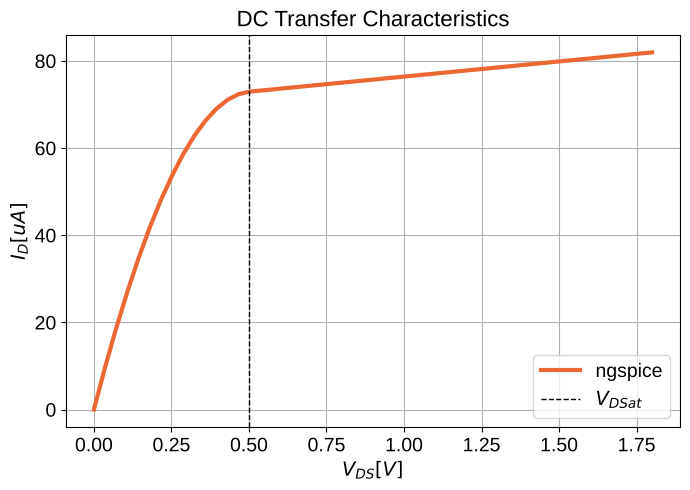

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(vdsn_dc, id_u1_dc*1e6, linewidth=3, color=C_NGSPICE, label='ngspice')
plt.axvline(vdsat_u1, color='k', linestyle='--', linewidth=1, label=r'$V_{DSat}$')
plt.legend(prop={"size": 14, 'weight': 'normal'}, loc="lower right")
plt.title('DC Transfer Characteristics', weight='normal', fontsize=16)
plt.xlabel(r'$V_{DS} [V]$', weight='normal', fontsize=14)
plt.ylabel(r'$I_{D} [uA]$', weight='normal', fontsize=14)
plt.xticks(weight='normal', fontsize=14)
plt.yticks(weight='normal', fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()

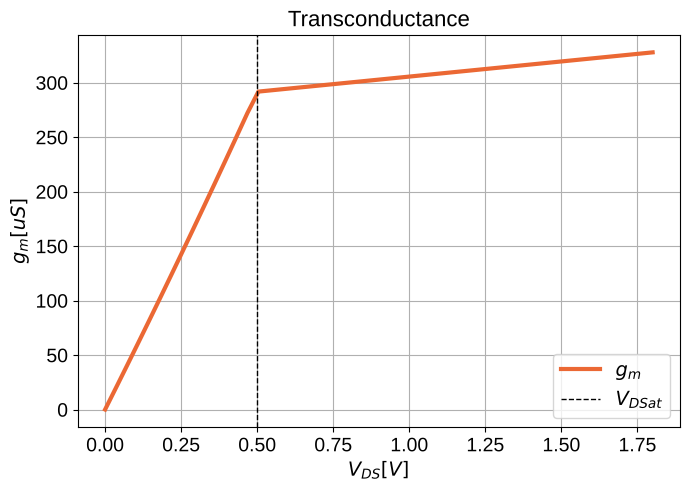

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(vdsn_dc, gm_u1_dc*1e6, linewidth=3, color=C_NGSPICE, label=r'$g_m$')
plt.axvline(vdsat_u1, color='k', linestyle='--', linewidth=1, label=r'$V_{DSat}$')
plt.legend(prop={"size": 14, 'weight': 'normal'}, loc="lower right")
plt.title('Transconductance', weight='normal', fontsize=16)
plt.xlabel(r'$V_{DS} [V]$', weight='normal', fontsize=14)
plt.ylabel(r'$g_{m} [uS]$', weight='normal', fontsize=14)
plt.xticks(weight='normal', fontsize=14)
plt.yticks(weight='normal', fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()

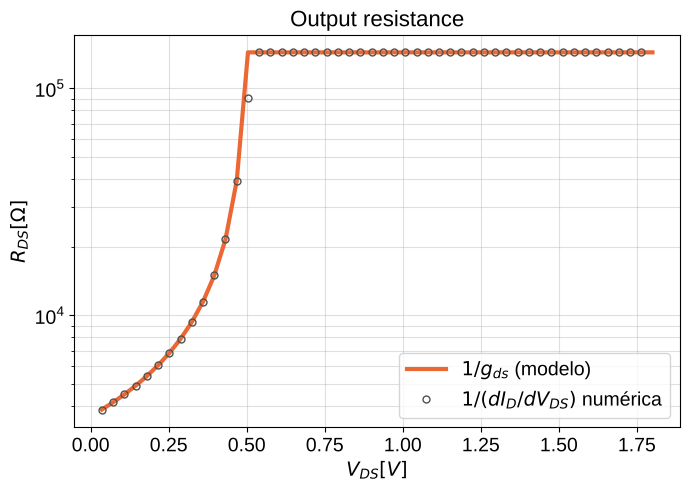

In [8]:
plt.figure(figsize=(7, 5))
plt.semilogy(vdsn_dc[1:], rds_u1_dc[1:], linewidth=3, color=C_NGSPICE, label=r'$1/g_{ds}$ (modelo)')
plt.semilogy(vdsn_dc[1:-1], 1/gds_num_dc[1:-1], 'o', markersize=5, mfc='none', color=C_LTSPICE,
             label=r'$1/(dI_D/dV_{DS})$ numérica')
plt.legend(prop={"size": 14, 'weight': 'normal'}, loc="lower right")
plt.title('Output resistance', weight='normal', fontsize=16)
plt.xlabel(r'$V_{DS} [V]$', weight='normal', fontsize=14)
plt.ylabel(r'$R_{DS} [Ω]$', weight='normal', fontsize=14)
plt.xticks(weight='normal', fontsize=14)
plt.yticks(weight='normal', fontsize=14)
plt.grid(which='both', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Comparación con LTspice
Si existe el `.raw` de LTspice (`../../LTspice/Razavi/DC_Sweep_Razavi.raw`), se superpone la curva de $I_D$ contra la de ngspice y se reporta la diferencia máxima. Ambos simuladores usan el mismo modelo Level 1 y el mismo barrido ($V_{DS}$ de 0 a 1.8 V, 51 puntos).

Diferencia máxima de ID entre ngspice y LTspice: 4.0 pA (4.9e-06 % del máximo)


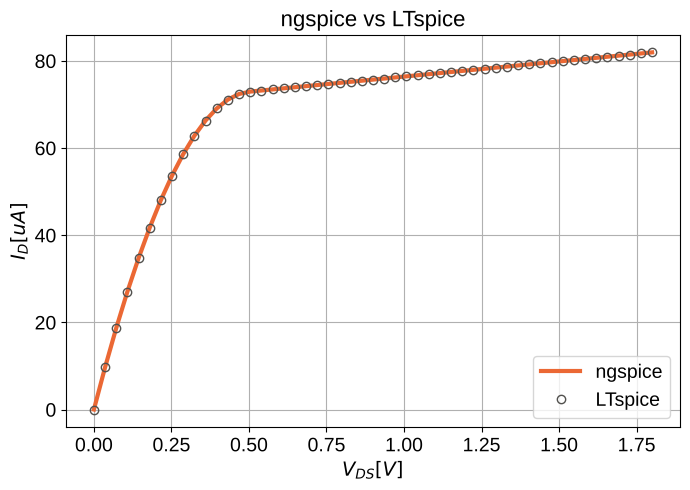

In [9]:
RAW_LTSPICE_DC = os.path.join("..", "..", "LTspice", "Razavi", "DC_Sweep_Razavi.raw")

if os.path.exists(RAW_LTSPICE_DC):
    raw_lt = RawRead(RAW_LTSPICE_DC)
    vds_lt = raw_lt.get_trace("V(vdsn)").get_wave()
    id_lt  = raw_lt.get_trace("Ix(u1:d)").get_wave()

    diff = np.abs(id_u1_dc - id_lt)
    print(f"Diferencia máxima de ID entre ngspice y LTspice: {num2eng(diff.max())}A "
          f"({diff.max()/id_lt.max()*100:.1e} % del máximo)")

    plt.figure(figsize=(7, 5))
    plt.plot(vdsn_dc, id_u1_dc*1e6, linewidth=3, color=C_NGSPICE, label='ngspice')
    plt.plot(vds_lt, id_lt*1e6, 'o', markersize=6, mfc='none', color=C_LTSPICE, label='LTspice')
    plt.legend(prop={"size": 14, 'weight': 'normal'}, loc="lower right")
    plt.title('ngspice vs LTspice', weight='normal', fontsize=16)
    plt.xlabel(r'$V_{DS} [V]$', weight='normal', fontsize=14)
    plt.ylabel(r'$I_{D} [uA]$', weight='normal', fontsize=14)
    plt.xticks(weight='normal', fontsize=14)
    plt.yticks(weight='normal', fontsize=14)
    plt.grid()
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró el .raw de LTspice; se omite la comparación.")